In [3]:
import pandas as pd
import yfinance as yf 
import numpy as np 
import matplotlib.pyplot as plt
import datetime
import seaborn as sns 

# まず、チャート情報を取得して、PER,PBR,などの計算をする

## 例としてツムラ株式会社の分析

In [4]:
dat = yf.Ticker("4540.T")
dat.calendar

{'Ex-Dividend Date': datetime.date(2026, 3, 30),
 'Earnings Date': [datetime.date(2026, 2, 6)],
 'Earnings High': None,
 'Earnings Low': None,
 'Earnings Average': None,
 'Revenue High': None,
 'Revenue Low': None,
 'Revenue Average': None}

In [5]:
dat.history(period='1mo')

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-10-14 00:00:00+09:00,3456.0,3507.0,3444.0,3467.0,739700,0.0,0.0
2025-10-15 00:00:00+09:00,3493.0,3519.0,3488.0,3496.0,296900,0.0,0.0
2025-10-16 00:00:00+09:00,3520.0,3546.0,3517.0,3540.0,308200,0.0,0.0
2025-10-17 00:00:00+09:00,3524.0,3557.0,3521.0,3539.0,224200,0.0,0.0
2025-10-20 00:00:00+09:00,3586.0,3616.0,3566.0,3599.0,418200,0.0,0.0
2025-10-21 00:00:00+09:00,3615.0,3659.0,3615.0,3634.0,448100,0.0,0.0
2025-10-22 00:00:00+09:00,3634.0,3666.0,3632.0,3639.0,453400,0.0,0.0
2025-10-23 00:00:00+09:00,3640.0,3674.0,3630.0,3648.0,316500,0.0,0.0
2025-10-24 00:00:00+09:00,3648.0,3663.0,3617.0,3622.0,261300,0.0,0.0


### basic information

In [6]:
info = dat.info

In [7]:
info

{'address1': '2-17-11, Akasaka',
 'address2': 'Minato-ku',
 'city': 'Tokyo',
 'zip': '107-8521',
 'country': 'Japan',
 'phone': '81 3 6361 7121',
 'website': 'https://www.tsumura.co.jp',
 'industry': 'Drug Manufacturers - Specialty & Generic',
 'industryKey': 'drug-manufacturers-specialty-generic',
 'industryDisp': 'Drug Manufacturers - Specialty & Generic',
 'sector': 'Healthcare',
 'sectorKey': 'healthcare',
 'sectorDisp': 'Healthcare',
 'longBusinessSummary': "Tsumura & Co. engages in the production and sale of Kampo extract intermediates and granular Kampo formulations in Japan and internationally. The company offers products for female problems, proneness to fatigue, skin problems, gastrointestinal problems, obesity, constipation and hemorrhoids, as well as body aches, children's sickness, stress, urinary problems, and cold, cough, and nasal and throat inflammation symptoms. It also offers over-the-counter Kampo medicines. The company was founded in 1893 and is headquartered in To

In [8]:
print(info['trailingPE']) #PER last 12month 
print(info['forwardPE']) # PER in the future prediction
print(info['priceToBook']) # PBR
print(info['trailingEps']) # EPS #過去12ヶ月のEPS（1株あたり利益）
print(info['lastDividendDate'])
timestamp = info['lastDividendDate']
date_object = datetime.datetime.fromtimestamp(timestamp)

print(date_object)

10.857773
9.44092
1.0192416
363.15
1774828800
2026-03-30 09:00:00


In [9]:
calendar_info = dat.calendar

# pandas.DataFrame形式で表示されます
print("--- カレンダー情報全体 ---")
print(calendar_info)

--- カレンダー情報全体 ---
{'Ex-Dividend Date': datetime.date(2026, 3, 30), 'Earnings Date': [datetime.date(2026, 2, 6)], 'Earnings High': None, 'Earnings Low': None, 'Earnings Average': None, 'Revenue High': None, 'Revenue Low': None, 'Revenue Average': None}


### Ticker Visualization

In [10]:
ticker = "4540.T"  # トヨタ自動車
df = yf.download(ticker, start="2023-01-01", end="2025-11-10")

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_94428/1939077804.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2023-01-01", end="2025-11-10")
[*********************100%***********************]  1 of 1 completed


In [11]:
df = df.reset_index().copy()
df.columns = ['Date', "Close", "High", "Low", "Open", "Volume"]
df

,Date,Close,High,Low,Open,Volume
0,2023-01-04,2585.949951,2645.555181,2580.447930,2631.800128,201000
1,2023-01-05,2548.352539,2578.613652,2547.435536,2578.613652,155300
2,2023-01-06,2517.174316,2541.933408,2510.755293,2523.593340,181900
3,2023-01-10,2481.411377,2523.593536,2481.411377,2511.672491,160500
4,2023-01-11,2482.328125,2512.589236,2480.494118,2503.419203,142200
...,...,...,...,...,...,...
693,2025-10-31,3575.000000,3584.000000,3545.000000,3582.000000,309800
694,2025-11-04,3579.000000,3614.000000,3558.000000,3567.000000,299200
695,2025-11-05,3553.000000,3614.000000,3525.000000,3600.000000,245600
696,2025-11-06,3543.000000,3573.000000,3542.000000,3553.000000,180800


In [12]:
past_ernings = dat.earnings_dates
earnings_only_df = past_earnings[past_earnings['Event Type'] == 'Earnings']

# フィルタリングされた日付リスト（インデックス）を取得
earnings_dates_list = earnings_only_df.index

# （参考） フィルタリングされた内容を確認
print("--- 'Earnings' のみ抽出 ---")
print(earnings_only_df)


NameError: name 'past_earnings' is not defined

In [13]:
# (A) 過去の決算日を取得
past_earnings = dat.earnings_dates
if 'Event Type' in past_earnings.columns:
    earnings_only_df = past_earnings[past_earnings['Event Type'] == 'Earnings']
    earnings_dates_list = earnings_only_df.index
else:
    earnings_dates_list = past_earnings.index

earnings_dates_list

DatetimeIndex(['2025-05-12 11:30:00+09:00', '2025-02-06 15:00:00+09:00',
               '2024-11-07 15:00:00+09:00', '2024-08-05 15:00:00+09:00',
               '2024-05-09 15:00:00+09:00', '2024-02-06 15:00:00+09:00',
               '2023-11-07 15:00:00+09:00', '2023-08-03 15:00:00+09:00',
               '2023-05-09 15:00:00+09:00'],
              dtype='datetime64[ns, Asia/Tokyo]', name='Earnings Date', freq=None)

In [14]:
past_dividends = dat.dividends
dividend_dates_list = past_dividends.index
dividend_dates_list = dividend_dates_list[37:]

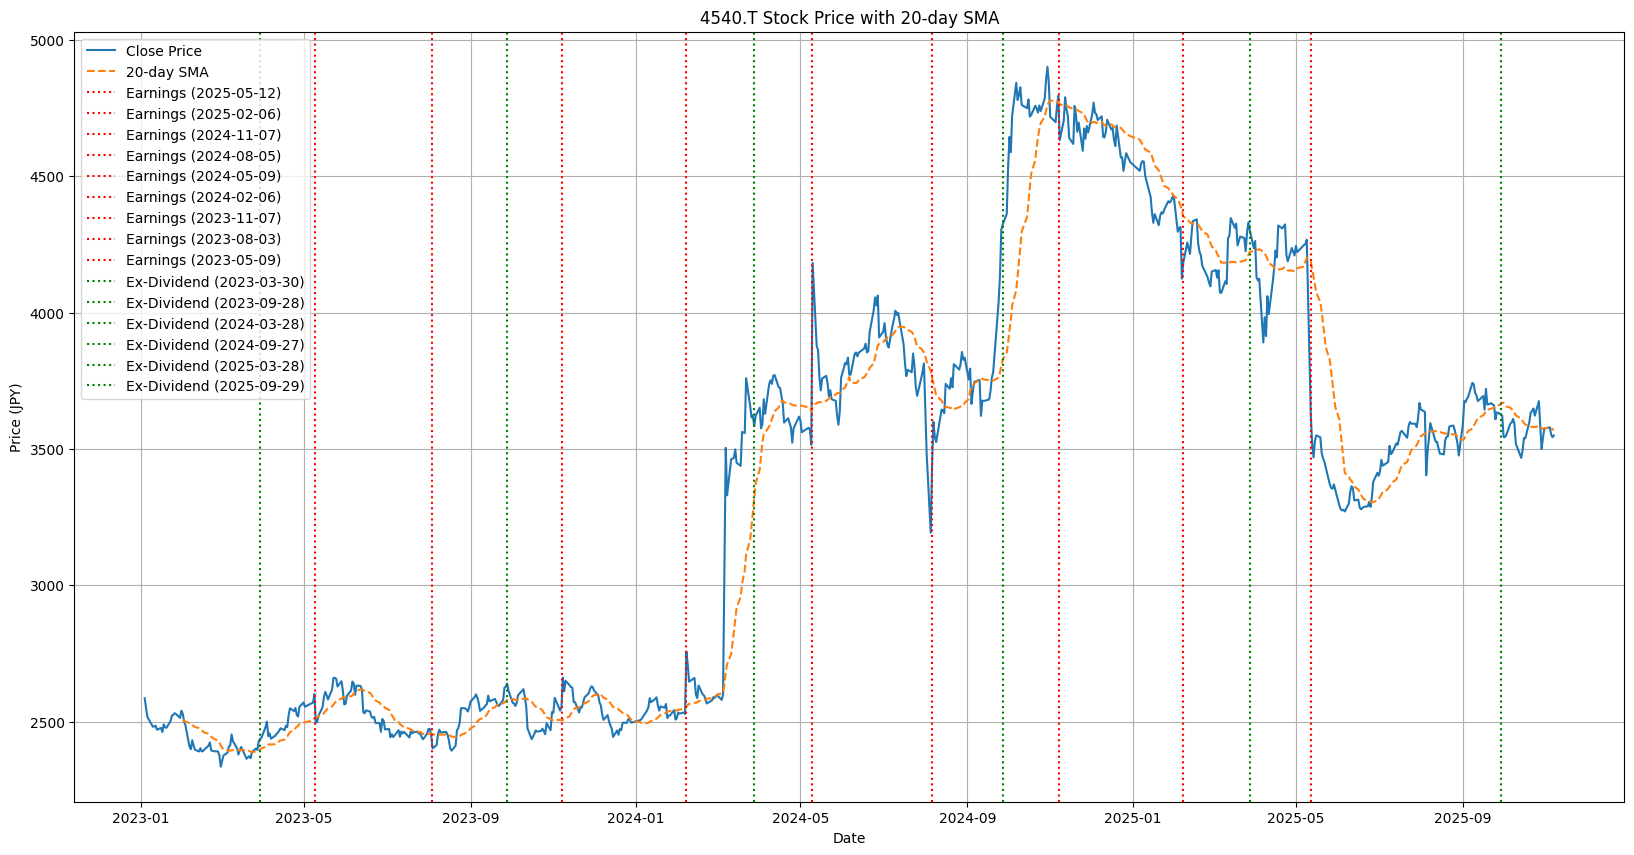

In [15]:
df["SMA_20"] = df["Close"].rolling(window=20).mean()
# プロット
plt.figure(figsize=(20,10))
plt.plot(df['Date'],df["Close"], label="Close Price")
plt.plot(df['Date'],df["SMA_20"], label="20-day SMA", linestyle='--')
plt.title(f"{ticker} Stock Price with 20-day SMA")
for earnings_date in earnings_dates_list:
    
    # タイムゾーン情報を除去
    earnings_date_naive = earnings_date.tz_localize(None)
    
    plt.axvline(x=earnings_date_naive, color='red', linestyle=':', 
                    label=f"Earnings ({earnings_date_naive.strftime('%Y-%m-%d')})")
    
for div_date in dividend_dates_list:
    
    # タイムゾーン情報を除去
    div_date_naive = div_date.tz_localize(None)

    plt.axvline(x=div_date_naive, color='green', linestyle=':', 
                    label=f"Ex-Dividend ({div_date_naive.strftime('%Y-%m-%d')})")
        

plt.xlabel("Date")
plt.xlim()
plt.ylabel("Price (JPY)")
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# PBRなどの指標を求めるのと、Critical Event（決算発表時などに線を入れたい）
def analyze_table(codes):
    l = []
    for code in codes:
        dat = yf.Ticker(code)
        info = dat.info
        past_earnings = dat.earnings_dates
        per = info['trailingPE']
        per_future = info['forwardPE']
        pbr = info['priceToBook']
        eps = info['trailingEps']
        divid = info['dividendYield']
        margin = info['operatingMargins']
        promargin = info['profitMargins']
        marketcap = info['marketCap']

        l.append({'Code':code,'PER':per,'Future_PER':per_future,
                'PBR':pbr,'EPS':eps,'Dividend_Yield':divid,'Operating_Margin':margin
                ,'Profit_Margin':promargin,'Market_cap':marketcap})
    
    return pd.DataFrame(l)

In [17]:
x = analyze_table(['4540.T'])
x

,Code,PER,Future_PER,PBR,EPS,Dividend_Yield,Operating_Margin,Profit_Margin,Market_cap
0,4540.T,10.857773,9.44092,1.019242,363.15,3.85,0.17914,0.14191,294566723584


/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_94428/815201888.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


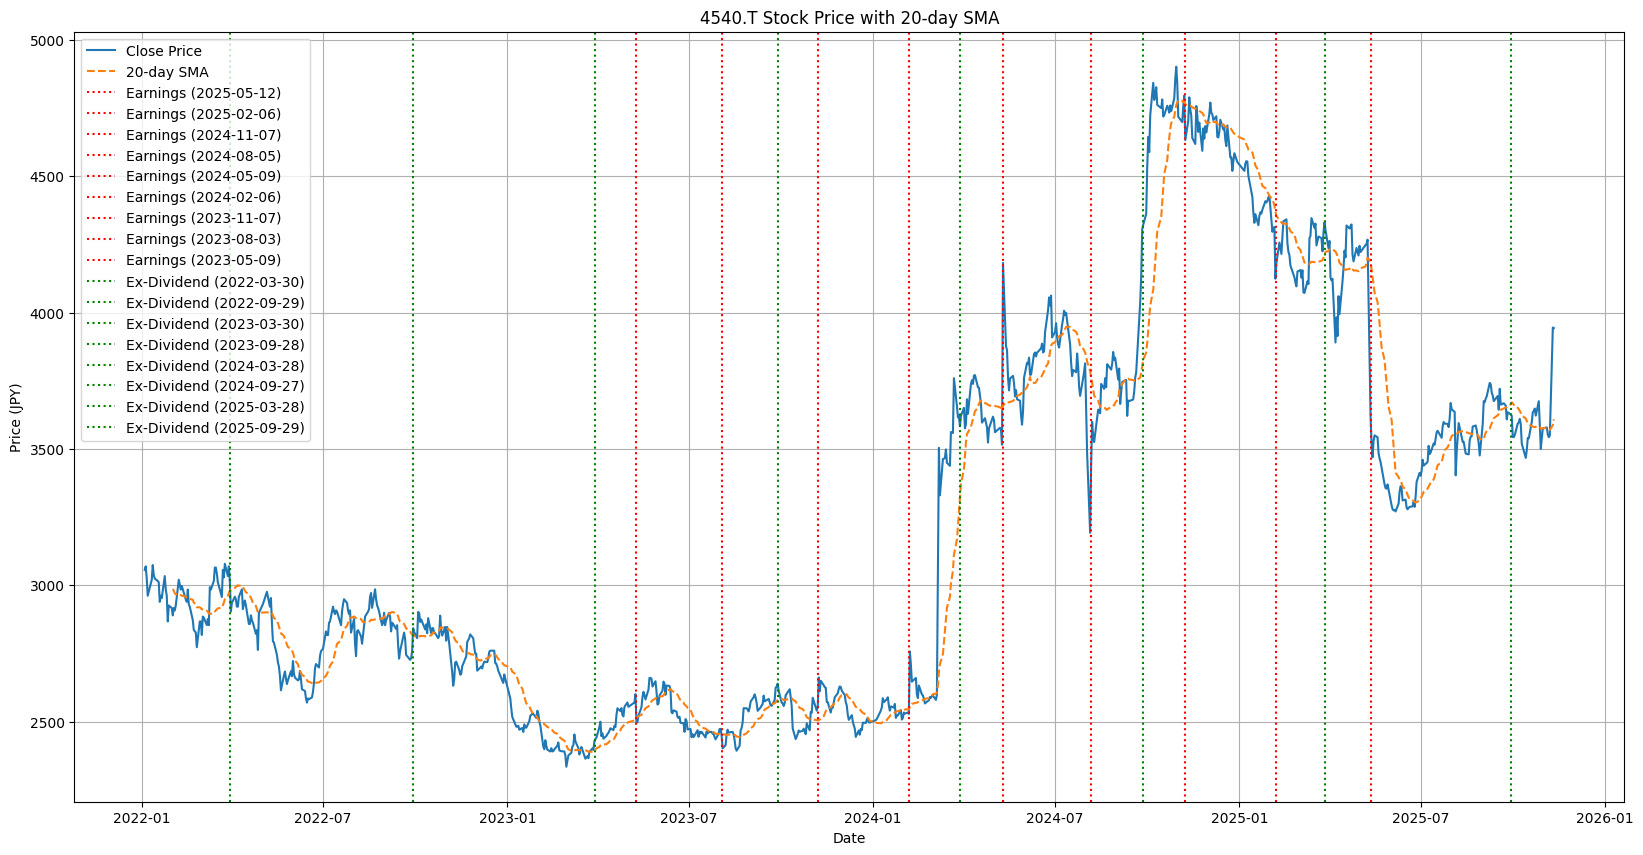

In [19]:
# 一連の流れ：
def plot(code,start,end):
    ticker = code  # トヨタ自動車
    # df = yf.download(ticker, start="2023-01-01", end="2025-11-10")
    df = yf.download(ticker, start, end)
    
    df = df.reset_index().copy()
    df.columns = ['Date', "Close", "High", "Low", "Open", "Volume"]

    # (A) 過去の決算日を取得
    past_earnings = dat.earnings_dates
    if 'Event Type' in past_earnings.columns:
        earnings_only_df = past_earnings[past_earnings['Event Type'] == 'Earnings']
        earnings_dates_list = earnings_only_df.index
    else:
        earnings_dates_list = past_earnings.index

    past_dividends = dat.dividends
    dividend_dates_list = past_dividends.index
    dividend_dates_list = dividend_dates_list[35:]
    
    
    df["SMA_20"] = df["Close"].rolling(window=20).mean()
    # プロット
    plt.figure(figsize=(20,10))
    plt.plot(df['Date'],df["Close"], label="Close Price")
    plt.plot(df['Date'],df["SMA_20"], label="20-day SMA", linestyle='--')
    plt.title(f"{ticker} Stock Price with 20-day SMA")
    for earnings_date in earnings_dates_list:
        
        # タイムゾーン情報を除去
        earnings_date_naive = earnings_date.tz_localize(None)
        
        plt.axvline(x=earnings_date_naive, color='red', linestyle=':', 
                        label=f"Earnings ({earnings_date_naive.strftime('%Y-%m-%d')})")
        
    for div_date in dividend_dates_list:
        
        # タイムゾーン情報を除去
        div_date_naive = div_date.tz_localize(None)

        plt.axvline(x=div_date_naive, color='green', linestyle=':', 
                        label=f"Ex-Dividend ({div_date_naive.strftime('%Y-%m-%d')})")
            

    plt.xlabel("Date")
    plt.xlim()
    plt.ylabel("Price (JPY)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot('4540.T',"2022-01-01",'2026-11-12')

## ツムラと比較する医薬品業界のコードを取得する

In [192]:
import pandas as pd

def get_sector_codes(sector_name="医薬品"):
    """
    JPXから上場銘柄一覧を取得し、指定されたセクターの銘柄コードリストを返す
    """
    
    # 1. JPXの上場銘柄一覧ExcelファイルのURL
    # (URLが変更される可能性はありますが、近年はこのURLで安定しています)
    url = "https://www.jpx.co.jp/markets/statistics-equities/misc/tvdivq0000001vg2-att/data_j.xls"
    
    print(f"{url} からデータを読み込んでいます...")
    
    try:
        # 2. Excelファイルをpandasで直接読み込む
        # (注: JPXのファイルは古い.xls形式のため、openpyxl が必要になる場合があります)
        # (注: 最初の行がヘッダー（列名）です)
        df = pd.read_excel(url)
    except Exception as e:
        print(f"エラー: Excelファイルの読み込みに失敗しました。 {e}")
        print("必要なライブラリがインストールされていない可能性があります。")
        print("pip install openpyxl xlrd")
        return []

    # 3. 必要な列を抽出
    # JPXのExcelでは、業種は「33業種区分」、銘柄コードは「コード」という列名です。
    if '33業種区分' not in df.columns or 'コード' not in df.columns:
        print("エラー: 予期した列名（'33業種区分', 'コード'）が見つかりません。")
        print(f"実際の列名: {df.columns.tolist()}")
        return []

    # 4. 業種でフィルタリング
    sector_df = df[df['33業種区分'] == sector_name]
    
    if sector_df.empty:
        print(f"'{sector_name}' に一致する銘柄が見つかりませんでした。")
        return []
    
    # 5. 銘柄コードを抽出し、yfinance用の ".T" サフィックスを追加
    # (JPXのコードは整数型で提供されるため、文字列に変換します)
    codes_with_suffix = sector_df['コード'].astype(str) + '.T'
    
    # リストにして返す
    return codes_with_suffix.tolist()

# --- 関数の実行 ---
pharma_codes = get_sector_codes(sector_name="医薬品")

if pharma_codes:
    print(f"\n医薬品セクターの銘柄数: {len(pharma_codes)} 件")
    print("--- 最初の10件 ---")
    print(pharma_codes[:10])
    
    print("\n--- 最後の10件 ---")
    print(pharma_codes[-10:])

# (参考) 他の業種を指定することも可能
# electric_codes = get_sector_codes(sector_name="電気機器")
# print(f"\n電気機器セクターの銘柄数: {len(electric_codes)} 件")

https://www.jpx.co.jp/markets/statistics-equities/misc/tvdivq0000001vg2-att/data_j.xls からデータを読み込んでいます...

医薬品セクターの銘柄数: 81 件
--- 最初の10件 ---
['130A.T', '190A.T', '197A.T', '206A.T', '2160.T', '219A.T', '311A.T', '4151.T', '4502.T', '4503.T']

--- 最後の10件 ---
['4886.T', '4887.T', '4888.T', '4889.T', '4890.T', '4891.T', '4892.T', '4893.T', '4894.T', '4896.T']


In [124]:
len(pharma_codes)

81

In [169]:
# 小林製薬 4967
# ロート　4527
# ジェイふろ　2934 error
xx = analyze_table(codes=['4540.T','4527.T','4967.T'])
xx

,Code,PER,Future_PER,PBR,EPS,Dividend_Yield,Operating_Margin,Profit_Margin,Market_cap
0,4540.T,9.084952,9.294865,1.003473,427.30,3.83,0.17914,0.14191,290009645056
1,4527.T,17.923900,14.518252,2.055154,135.35,1.74,0.14185,0.10642,548189601792
2,4967.T,33.587543,22.569988,1.902370,158.66,1.95,0.11450,0.07306,396151554048


In [186]:
import warnings 
import japanize_matplotlib

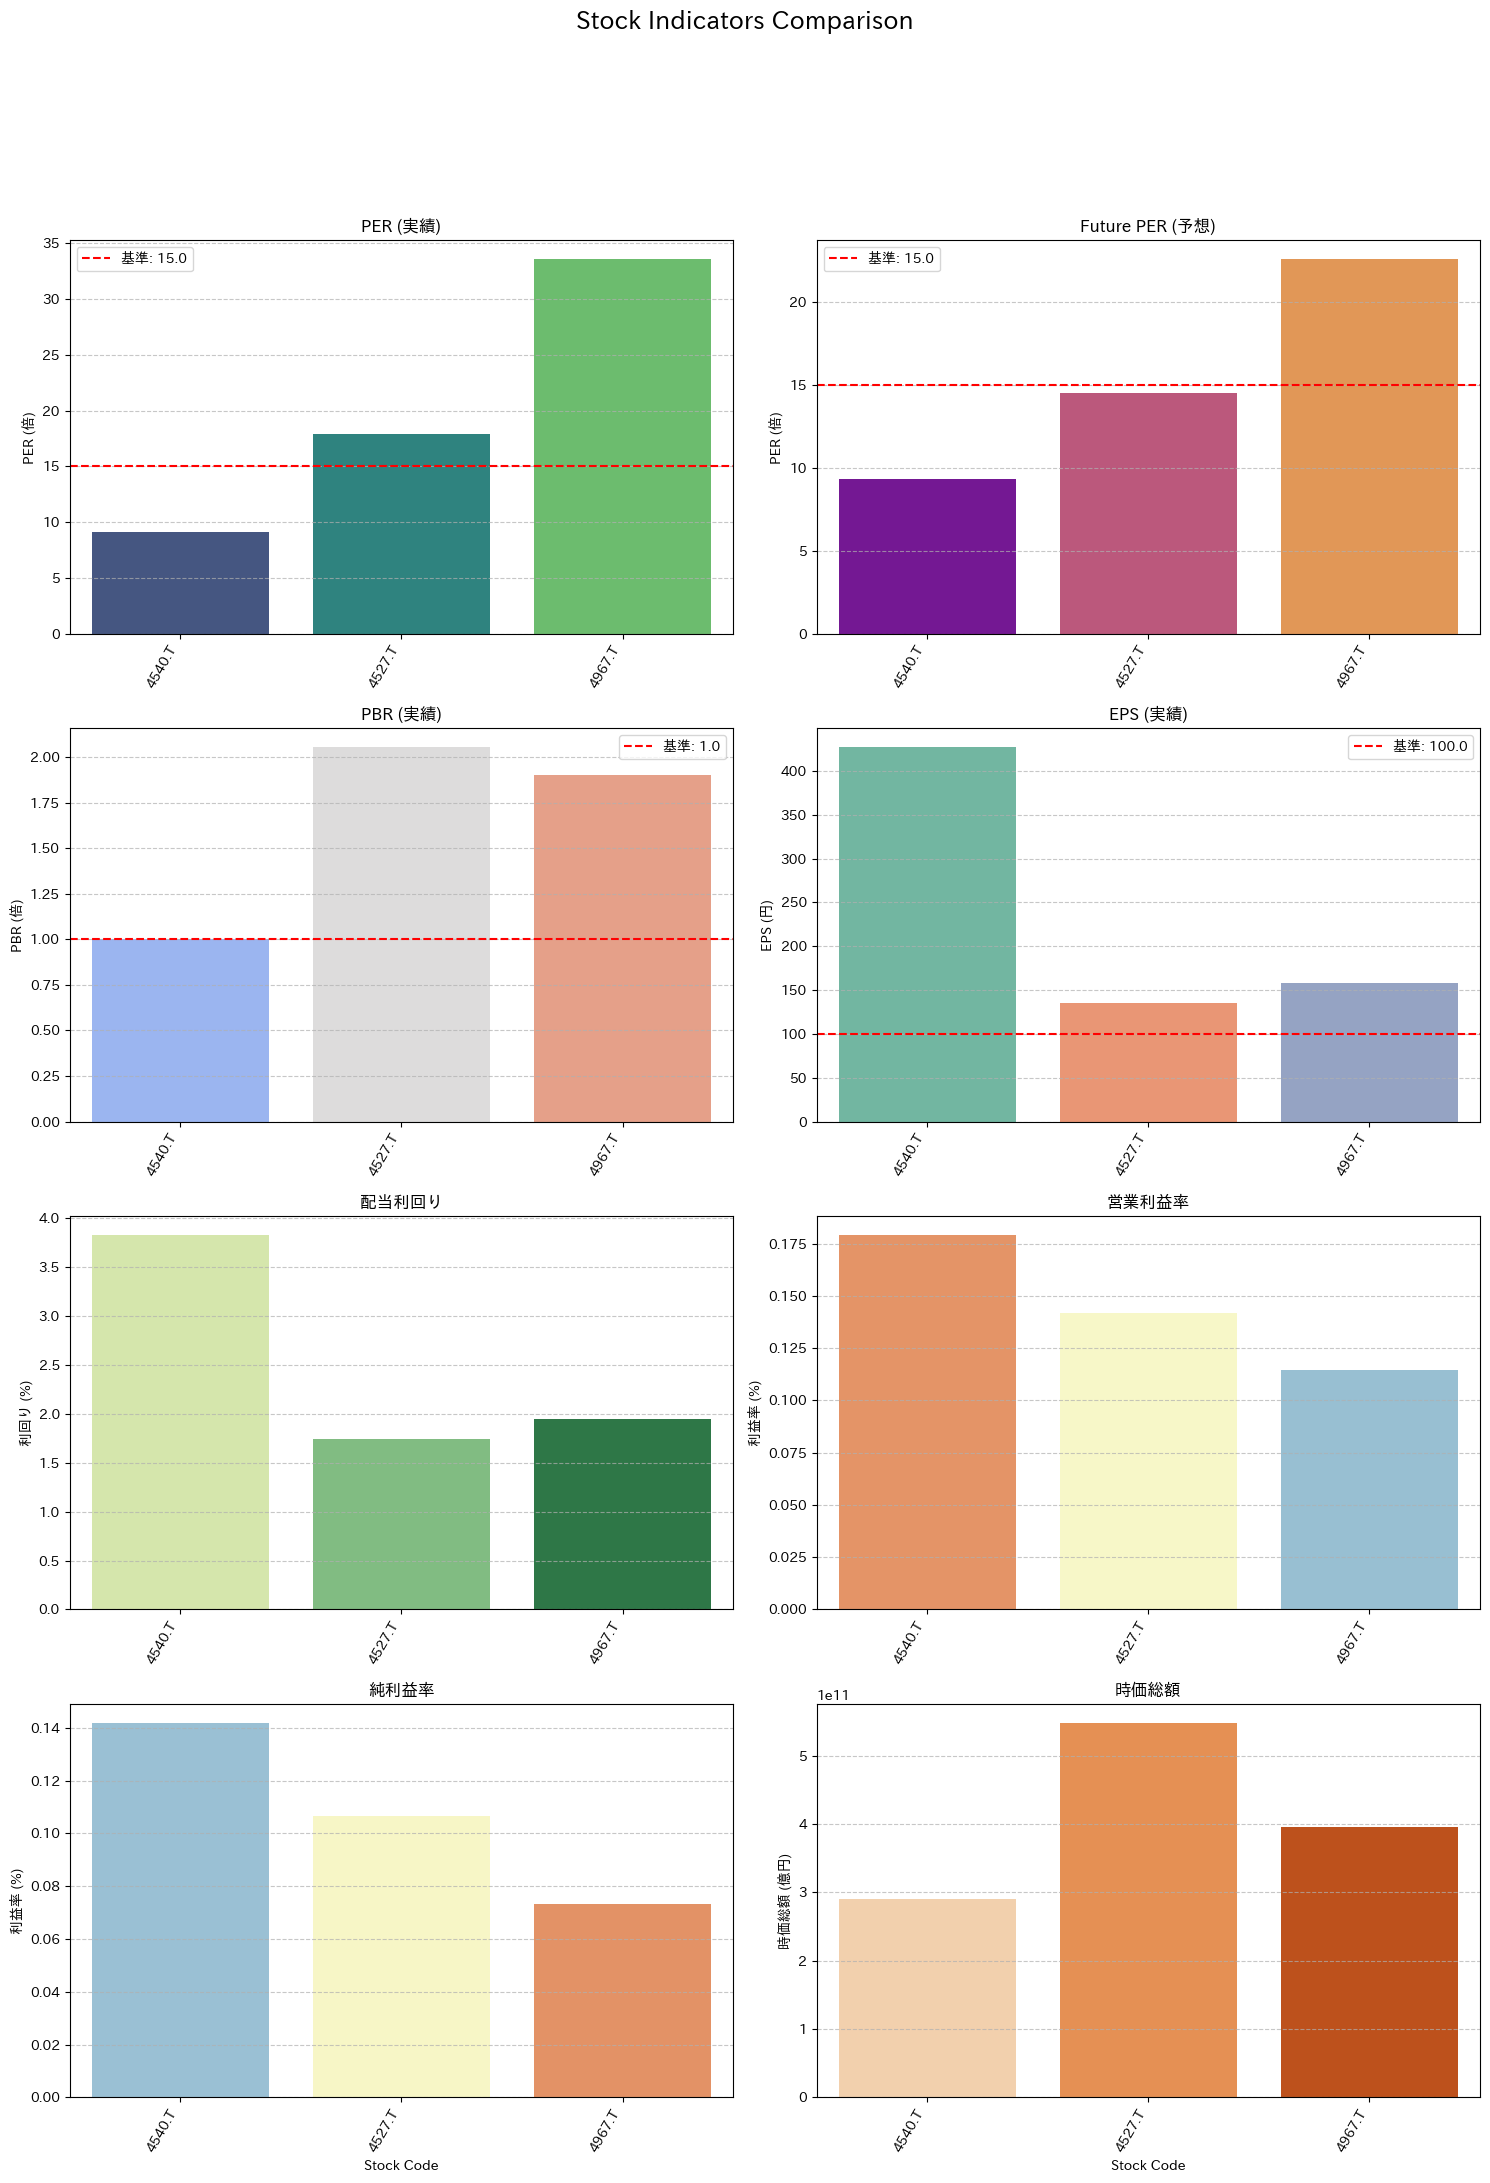

In [187]:
# --- 2. グラフの基準値をここで指定 ---
per_ref_line = 15.0      # PERの基準線
future_per_ref_line = 15.0 # Future PERの基準線
pbr_ref_line = 1.0       # PBRの基準線 (例: 1倍)
eps_ref_line = 100.0     # EPSの基準線 (例: 100円)





# --- 2. 4行2列のサブプロットを作成 ---
# (レイアウト (4, 2) は正しいです)
fig, ax = plt.subplots(4, 2, figsize=(15, 22)) # figsizeを (15, 22) に調整
fig.suptitle('Stock Indicators Comparison', fontsize=18, y=1.02)

# --- 1行目 (基準線あり) ---
# プロット 1: PER (0,0)
sns.barplot(x='Code', y='PER', data=xx, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('PER (実績)')
ax[0,0].set_ylabel('PER (倍)')
ax[0,0].axhline(y=per_ref_line, color='red', linestyle='--', label=f'基準: {per_ref_line}')
ax[0,0].legend() 

# プロット 2: Future PER (0,1)
sns.barplot(x='Code', y='Future_PER', data=xx, ax=ax[0,1], palette='plasma')
ax[0,1].set_title('Future PER (予想)')
ax[0,1].set_ylabel('PER (倍)')
ax[0,1].axhline(y=future_per_ref_line, color='red', linestyle='--', label=f'基準: {future_per_ref_line}')
ax[0,1].legend()

# --- 2行目 (基準線あり) ---
# プロット 3: PBR (1,0)
sns.barplot(x='Code', y='PBR', data=xx, ax=ax[1,0], palette='coolwarm')
ax[1,0].set_title('PBR (実績)')
ax[1,0].set_ylabel('PBR (倍)')
ax[1,0].axhline(y=pbr_ref_line, color='red', linestyle='--', label=f'基準: {pbr_ref_line}')
ax[1,0].legend()

# プロット 4: EPS (1,1)
sns.barplot(x='Code', y='EPS', data=xx, ax=ax[1,1], palette='Set2')
ax[1,1].set_title('EPS (実績)')
ax[1,1].set_ylabel('EPS (円)')
ax[1,1].axhline(y=eps_ref_line, color='red', linestyle='--', label=f'基準: {eps_ref_line}')
ax[1,1].legend()

# --- 3行目 (基準線なし) ---
# ▼ (修正) y= に正しい列名 'Dividend_Yield (%)' を指定
sns.barplot(x='Code', y='Dividend_Yield', data=xx, ax=ax[2,0], palette='YlGn')
ax[2,0].set_title('配当利回り')
ax[2,0].set_ylabel('利回り (%)')

# ▼ (修正) y= に正しい列名 'Operating_Margin (%)' を指定
sns.barplot(x='Code', y='Operating_Margin', data=xx, ax=ax[2,1], palette='RdYlBu')
ax[2,1].set_title('営業利益率')
ax[2,1].set_ylabel('利益率 (%)')

# --- 4行目 (基準線なし) ---
# ▼ (修正) y= に正しい列名 'Profit_Margin (%)' を指定
sns.barplot(x='Code', y='Profit_Margin', data=xx, ax=ax[3,0], palette='RdYlBu_r')
ax[3,0].set_title('純利益率')
ax[3,0].set_ylabel('利益率 (%)')

# ▼ (修正) 構文エラー (ax[3,]) を (ax[3,1]) に修正
# ▼ (修正) y= に正しい列名 'Market_cap (億円)' を指定
sns.barplot(x='Code', y='Market_cap', data=xx, ax=ax[3,1], palette='Oranges')
ax[3,1].set_title('時価総額')
ax[3,1].set_ylabel('時価総額 (億円)')


# --- 5. レイアウトの調整 ---
for subplot in ax.flat:
    # グリッドを追加
    subplot.grid(axis='y', linestyle='--', alpha=0.7)
    # X軸のラベルを回転
    subplot.set_xticklabels(subplot.get_xticklabels(), rotation=60, ha='right')
    subplot.set_xlabel('') # 各プロットのX軸ラベルは削除

# ▼ (修正) 一番下のプロット (4行目) にだけX軸ラベルを表示
ax[3,0].set_xlabel('Stock Code')
ax[3,1].set_xlabel('Stock Code')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

/var/folders/6g/w4z9zgn15ng21w8fwdt1bkpr0000gn/T/ipykernel_96831/4047600380.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start, end)
[*********************100%***********************]  1 of 1 completed


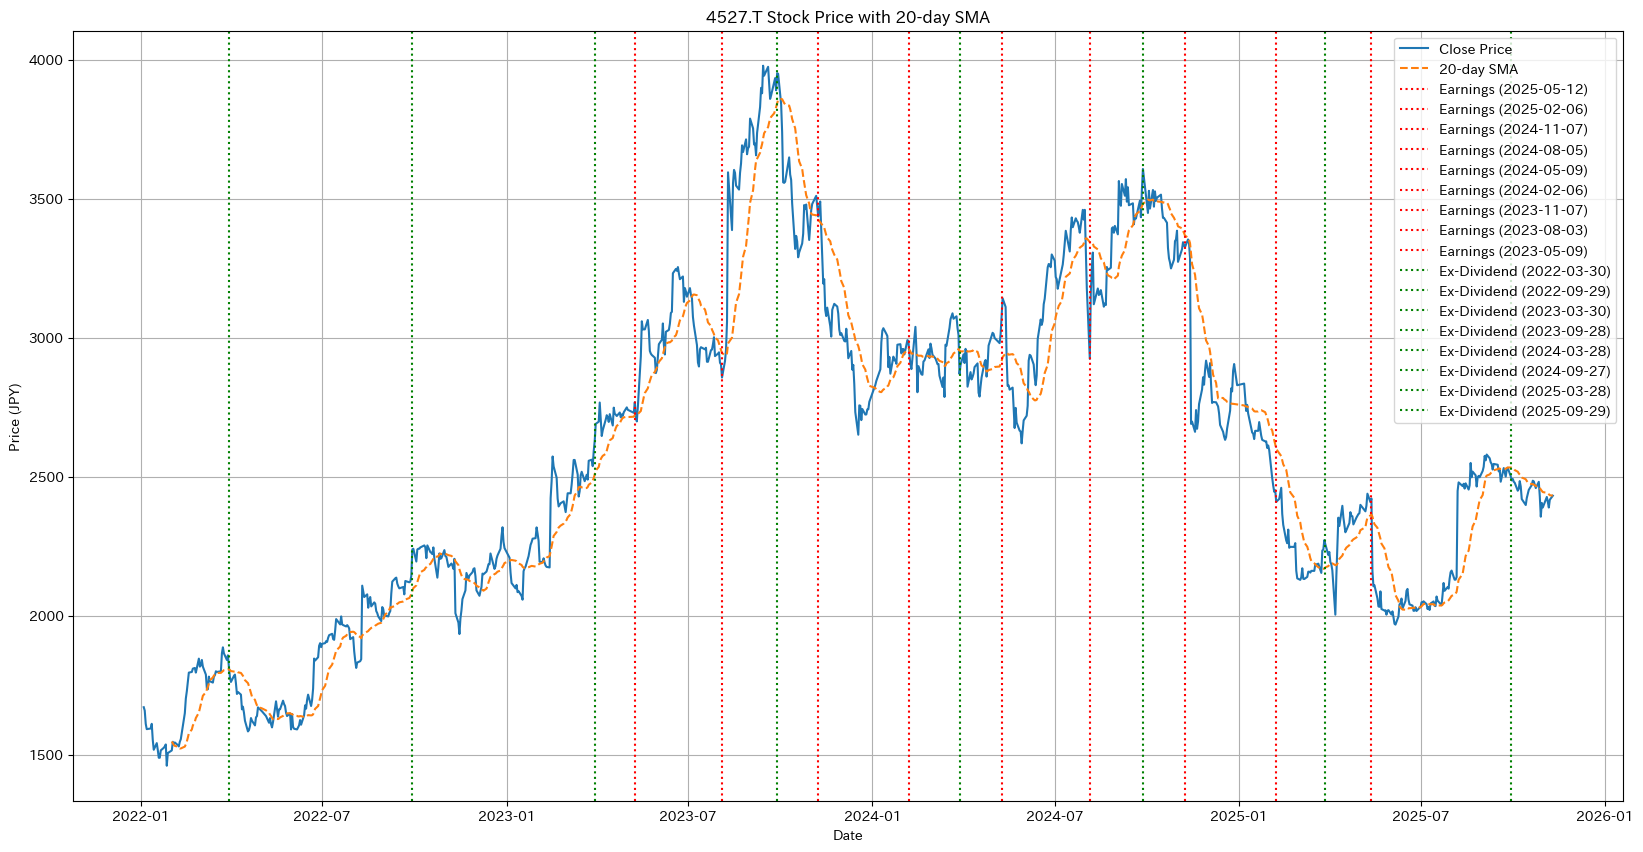

In [193]:
# 一連の流れ：
def plot(code,start,end):
    ticker = code  # トヨタ自動車
    # df = yf.download(ticker, start="2023-01-01", end="2025-11-10")
    df = yf.download(ticker, start, end)
    
    df = df.reset_index().copy()
    df.columns = ['Date', "Close", "High", "Low", "Open", "Volume"]

    # (A) 過去の決算日を取得
    past_earnings = dat.earnings_dates
    if 'Event Type' in past_earnings.columns:
        earnings_only_df = past_earnings[past_earnings['Event Type'] == 'Earnings']
        earnings_dates_list = earnings_only_df.index
    else:
        earnings_dates_list = past_earnings.index

    past_dividends = dat.dividends
    dividend_dates_list = past_dividends.index
    dividend_dates_list = dividend_dates_list[35:]
    
    
    df["SMA_20"] = df["Close"].rolling(window=20).mean()
    # プロット
    plt.figure(figsize=(20,10))
    plt.plot(df['Date'],df["Close"], label="Close Price")
    plt.plot(df['Date'],df["SMA_20"], label="20-day SMA", linestyle='--')
    plt.title(f"{ticker} Stock Price with 20-day SMA")
    for earnings_date in earnings_dates_list:
        
        # タイムゾーン情報を除去
        earnings_date_naive = earnings_date.tz_localize(None)
        
        plt.axvline(x=earnings_date_naive, color='red', linestyle=':', 
                        label=f"Earnings ({earnings_date_naive.strftime('%Y-%m-%d')})")
        
    for div_date in dividend_dates_list:
        
        # タイムゾーン情報を除去
        div_date_naive = div_date.tz_localize(None)

        plt.axvline(x=div_date_naive, color='green', linestyle=':', 
                        label=f"Ex-Dividend ({div_date_naive.strftime('%Y-%m-%d')})")
            

    plt.xlabel("Date")
    plt.xlim()
    plt.ylabel("Price (JPY)")
    plt.legend()
    plt.grid(True)
    plt.show()


plot('4527.T',"2022-01-01",'2026-11-10')

# 自動車でも同じことやる

In [ ]:
# 7201：日産自動車（にっさんじどうしゃ）株式会社

# 7202：いすゞ自動車（いすずじどうしゃ）株式会社

# 7203：トヨタ自動車（とよたじどうしゃ）株式会社

# 7205：日野自動車（ひのじどうしゃ）株式会社

# 7211：三菱自動車工業（みつびしじどうしゃこうぎょう）株式会社

# 7261：マツダ株式会社

# 7267：本田技研工業（ほんだぎけんこうぎょう）株式会社

# 7269：スズキ株式会社

# 7270：株式会社ＳＵＢＡＲＵ（スバル

In [209]:

def analyze_table_improved(codes):

    l = []
    for code in codes:
        dat = yf.Ticker(code)
        
        try:
            info = dat.info
            
            per = info.get('trailingPE', np.nan)
            per_future = info.get('forwardPE', np.nan)
            pbr = info.get('priceToBook', np.nan)
            eps = info.get('trailingEps', np.nan)
            divid = info.get('dividendYield', np.nan)
            margin = info.get('operatingMargins', np.nan)
            promargin = info.get('profitMargins', np.nan)
            marketcap = info.get('marketCap', np.nan)
            roe = info.get('returnOnEquity',np.nan)

            l.append({'Code': code, 'PER': per, 'Future_PER': per_future,
                      'PBR': pbr, 'EPS': eps, 'Dividend_Yield': divid, 'Operating_Margin': margin,
                      'Profit_Margin': promargin, 'Market_cap': marketcap,'ROE':roe})

        except Exception as e:
            print(f"Error processing {code}: {e}")
            l.append({'Code': code, 'PER': np.nan, 'Future_PER': np.nan,
                      'PBR': np.nan, 'EPS': np.nan, 'Dividend_Yield': np.nan, 'Operating_Margin': np.nan,
                      'Profit_Margin': np.nan, 'Market_cap': np.nan,'ROE':np.nan})
    
    return pd.DataFrame(l)


In [212]:
autolist=['7201.T', '7202.T', '7203.T', '7205.T', '7211.T', '7261.T', '7267.T', '7269.T', '7270.T']
auto = analyze_table_improved(autolist)

In [213]:
auto

,Code,PER,Future_PER,PBR,EPS,Dividend_Yield,Operating_Margin,Profit_Margin,Market_cap,ROE
0,7201.T,NaN,5.290102,0.262462,-255.86,NaN,0.01792,0.00000,1244994863104,NaN
1,7202.T,18.314915,7.620657,1.003346,105.87,4.79,0.07338,0.03838,1352843526144,0.10048
2,7203.T,8.815544,9.613842,1.083563,353.58,3.05,0.06783,0.09378,40625072242688,0.12938
3,7205.T,9.266683,8.877343,1.097110,42.41,NaN,0.05580,0.01529,225599537152,0.11853
4,7211.T,NaN,4.064212,0.572207,-3.71,2.75,0.01781,-0.00226,496322215936,0.00051
5,7261.T,5.955870,3.929223,0.390147,180.83,5.36,-0.00682,0.00688,679274283008,0.01950
6,7267.T,9.940789,6.623126,0.491868,152.00,4.42,0.03665,0.03034,5881605914624,0.05819
7,7269.T,10.967678,12.629787,1.376380,202.96,2.08,0.09161,0.06708,4294566477824,0.13892
8,7270.T,7.343275,7.533940,0.912527,457.97,3.48,0.06287,0.06425,2440129675264,0.11596


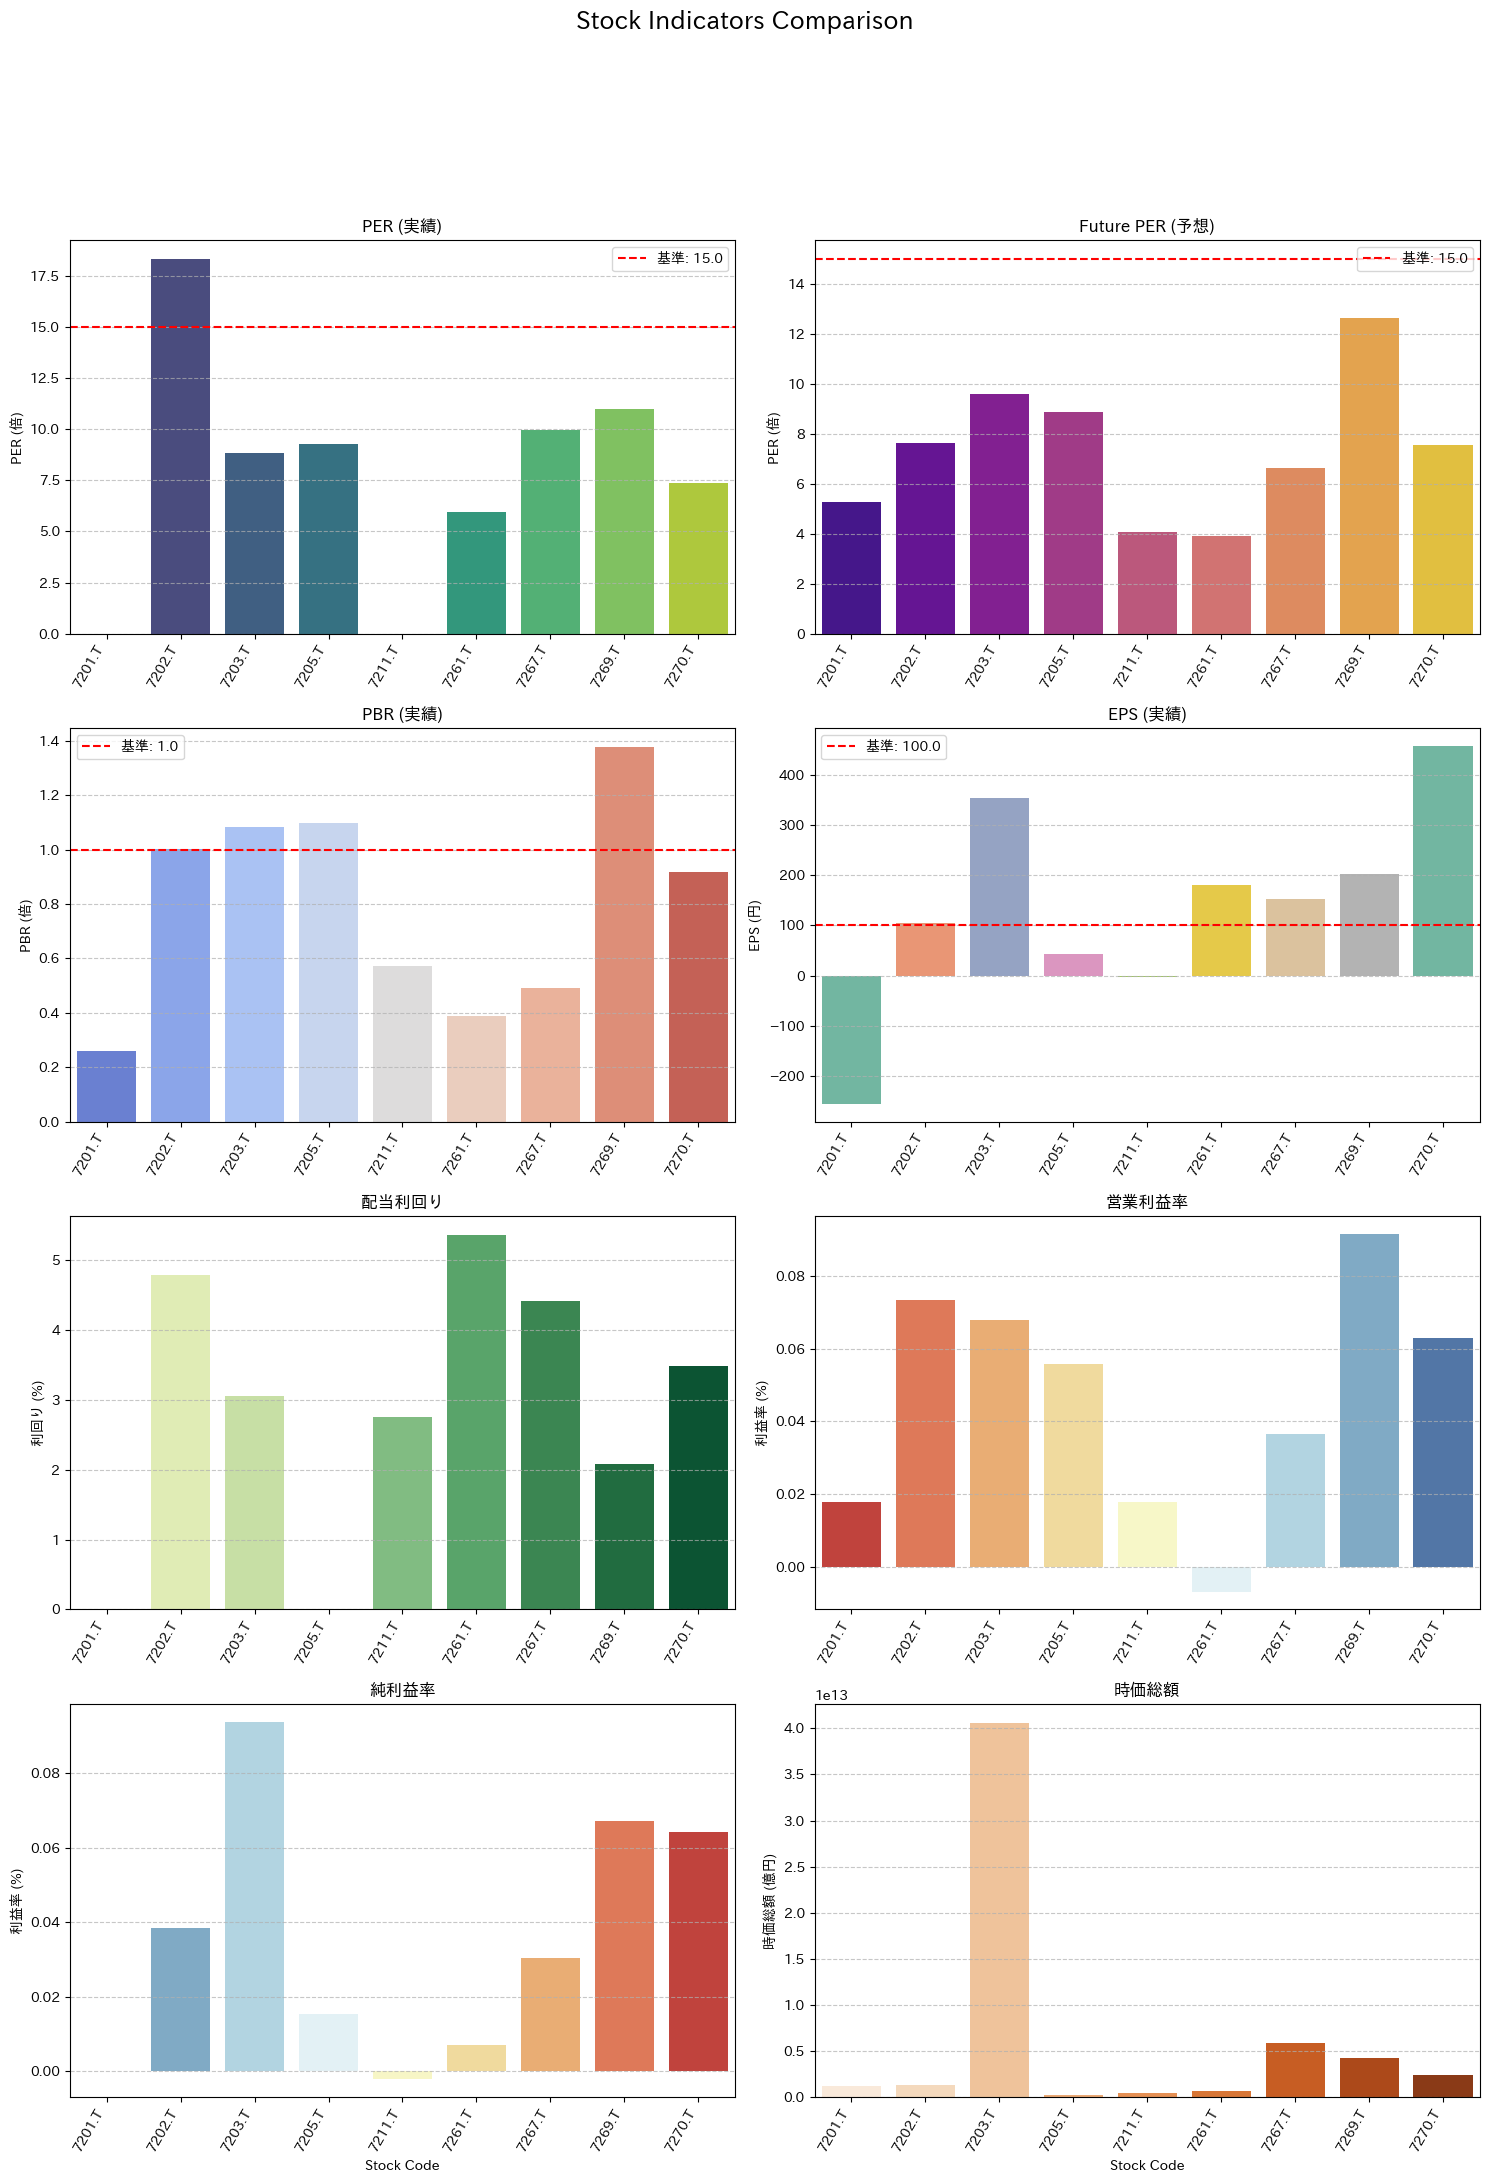

In [200]:

per_ref_line = 15.0      # PERの基準線
future_per_ref_line = 15.0 # Future PERの基準線
pbr_ref_line = 1.0       # PBRの基準線 (例: 1倍)
eps_ref_line = 100.0     # EPSの基準線 (例: 100円)


xx=auto


fig, ax = plt.subplots(4, 2, figsize=(15, 22)) # figsizeを (15, 22) に調整
fig.suptitle('Stock Indicators Comparison', fontsize=18, y=1.02)

# --- 1行目 (基準線あり) ---
# プロット 1: PER (0,0)
sns.barplot(x='Code', y='PER', data=xx, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('PER (実績)')
ax[0,0].set_ylabel('PER (倍)')
ax[0,0].axhline(y=per_ref_line, color='red', linestyle='--', label=f'基準: {per_ref_line}')
ax[0,0].legend() 

# プロット 2: Future PER (0,1)
sns.barplot(x='Code', y='Future_PER', data=xx, ax=ax[0,1], palette='plasma')
ax[0,1].set_title('Future PER (予想)')
ax[0,1].set_ylabel('PER (倍)')
ax[0,1].axhline(y=future_per_ref_line, color='red', linestyle='--', label=f'基準: {future_per_ref_line}')
ax[0,1].legend()

# --- 2行目 (基準線あり) ---
# プロット 3: PBR (1,0)
sns.barplot(x='Code', y='PBR', data=xx, ax=ax[1,0], palette='coolwarm')
ax[1,0].set_title('PBR (実績)')
ax[1,0].set_ylabel('PBR (倍)')
ax[1,0].axhline(y=pbr_ref_line, color='red', linestyle='--', label=f'基準: {pbr_ref_line}')
ax[1,0].legend()

# プロット 4: EPS (1,1)
sns.barplot(x='Code', y='EPS', data=xx, ax=ax[1,1], palette='Set2')
ax[1,1].set_title('EPS (実績)')
ax[1,1].set_ylabel('EPS (円)')
ax[1,1].axhline(y=eps_ref_line, color='red', linestyle='--', label=f'基準: {eps_ref_line}')
ax[1,1].legend()

# --- 3行目 (基準線なし) ---
# ▼ (修正) y= に正しい列名 'Dividend_Yield (%)' を指定
sns.barplot(x='Code', y='Dividend_Yield', data=xx, ax=ax[2,0], palette='YlGn')
ax[2,0].set_title('配当利回り')
ax[2,0].set_ylabel('利回り (%)')

# ▼ (修正) y= に正しい列名 'Operating_Margin (%)' を指定
sns.barplot(x='Code', y='Operating_Margin', data=xx, ax=ax[2,1], palette='RdYlBu')
ax[2,1].set_title('営業利益率')
ax[2,1].set_ylabel('利益率 (%)')

# --- 4行目 (基準線なし) ---
# ▼ (修正) y= に正しい列名 'Profit_Margin (%)' を指定
sns.barplot(x='Code', y='Profit_Margin', data=xx, ax=ax[3,0], palette='RdYlBu_r')
ax[3,0].set_title('純利益率')
ax[3,0].set_ylabel('利益率 (%)')

# ▼ (修正) 構文エラー (ax[3,]) を (ax[3,1]) に修正
# ▼ (修正) y= に正しい列名 'Market_cap (億円)' を指定
sns.barplot(x='Code', y='Market_cap', data=xx, ax=ax[3,1], palette='Oranges')
ax[3,1].set_title('時価総額')
ax[3,1].set_ylabel('時価総額 (億円)')


# --- 5. レイアウトの調整 ---
for subplot in ax.flat:
    # グリッドを追加
    subplot.grid(axis='y', linestyle='--', alpha=0.7)
    # X軸のラベルを回転
    subplot.set_xticklabels(subplot.get_xticklabels(), rotation=60, ha='right')
    subplot.set_xlabel('') # 各プロットのX軸ラベルは削除

# ▼ (修正) 一番下のプロット (4行目) にだけX軸ラベルを表示
ax[3,0].set_xlabel('Stock Code')
ax[3,1].set_xlabel('Stock Code')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## この流れで気になる銘柄を分析することはできる（基本的な関数は以上よりわかる）

### 実際に有効な値としては、可視化した部分のものなどである

In [201]:
# 詳しくはこのサイトを参照する
# https://bigdata-analytics.jp/for-beginners/stock_analysis/get-stock-price-python/

In [221]:
#NTT ソフトバンク 楽天　
# codes = ['9432.T','9434.T','4755.T']

# Yuatec , 日本ハウスホールディングス　７７銀行
codes = ['1934.T','1873.T','8341.T','2329.T']
xx = analyze_table_improved(codes)
xx

,Code,PER,Future_PER,PBR,EPS,Dividend_Yield,Operating_Margin,Profit_Margin,Market_cap,ROE
0,1934.T,13.129714,23.131971,1.157698,189.57,2.91,0.05987,0.04644,170898325504,0.08462
1,1873.T,10.821290,NaN,0.579547,28.37,3.59,-0.03828,0.01090,12279444480,NaN
2,8341.T,12.903409,26.587550,0.839773,529.55,3.15,0.43055,0.24904,506959167488,0.06707
3,2329.T,9.680542,NaN,0.961842,61.98,4.51,0.03642,0.00000,82592415744,0.10512


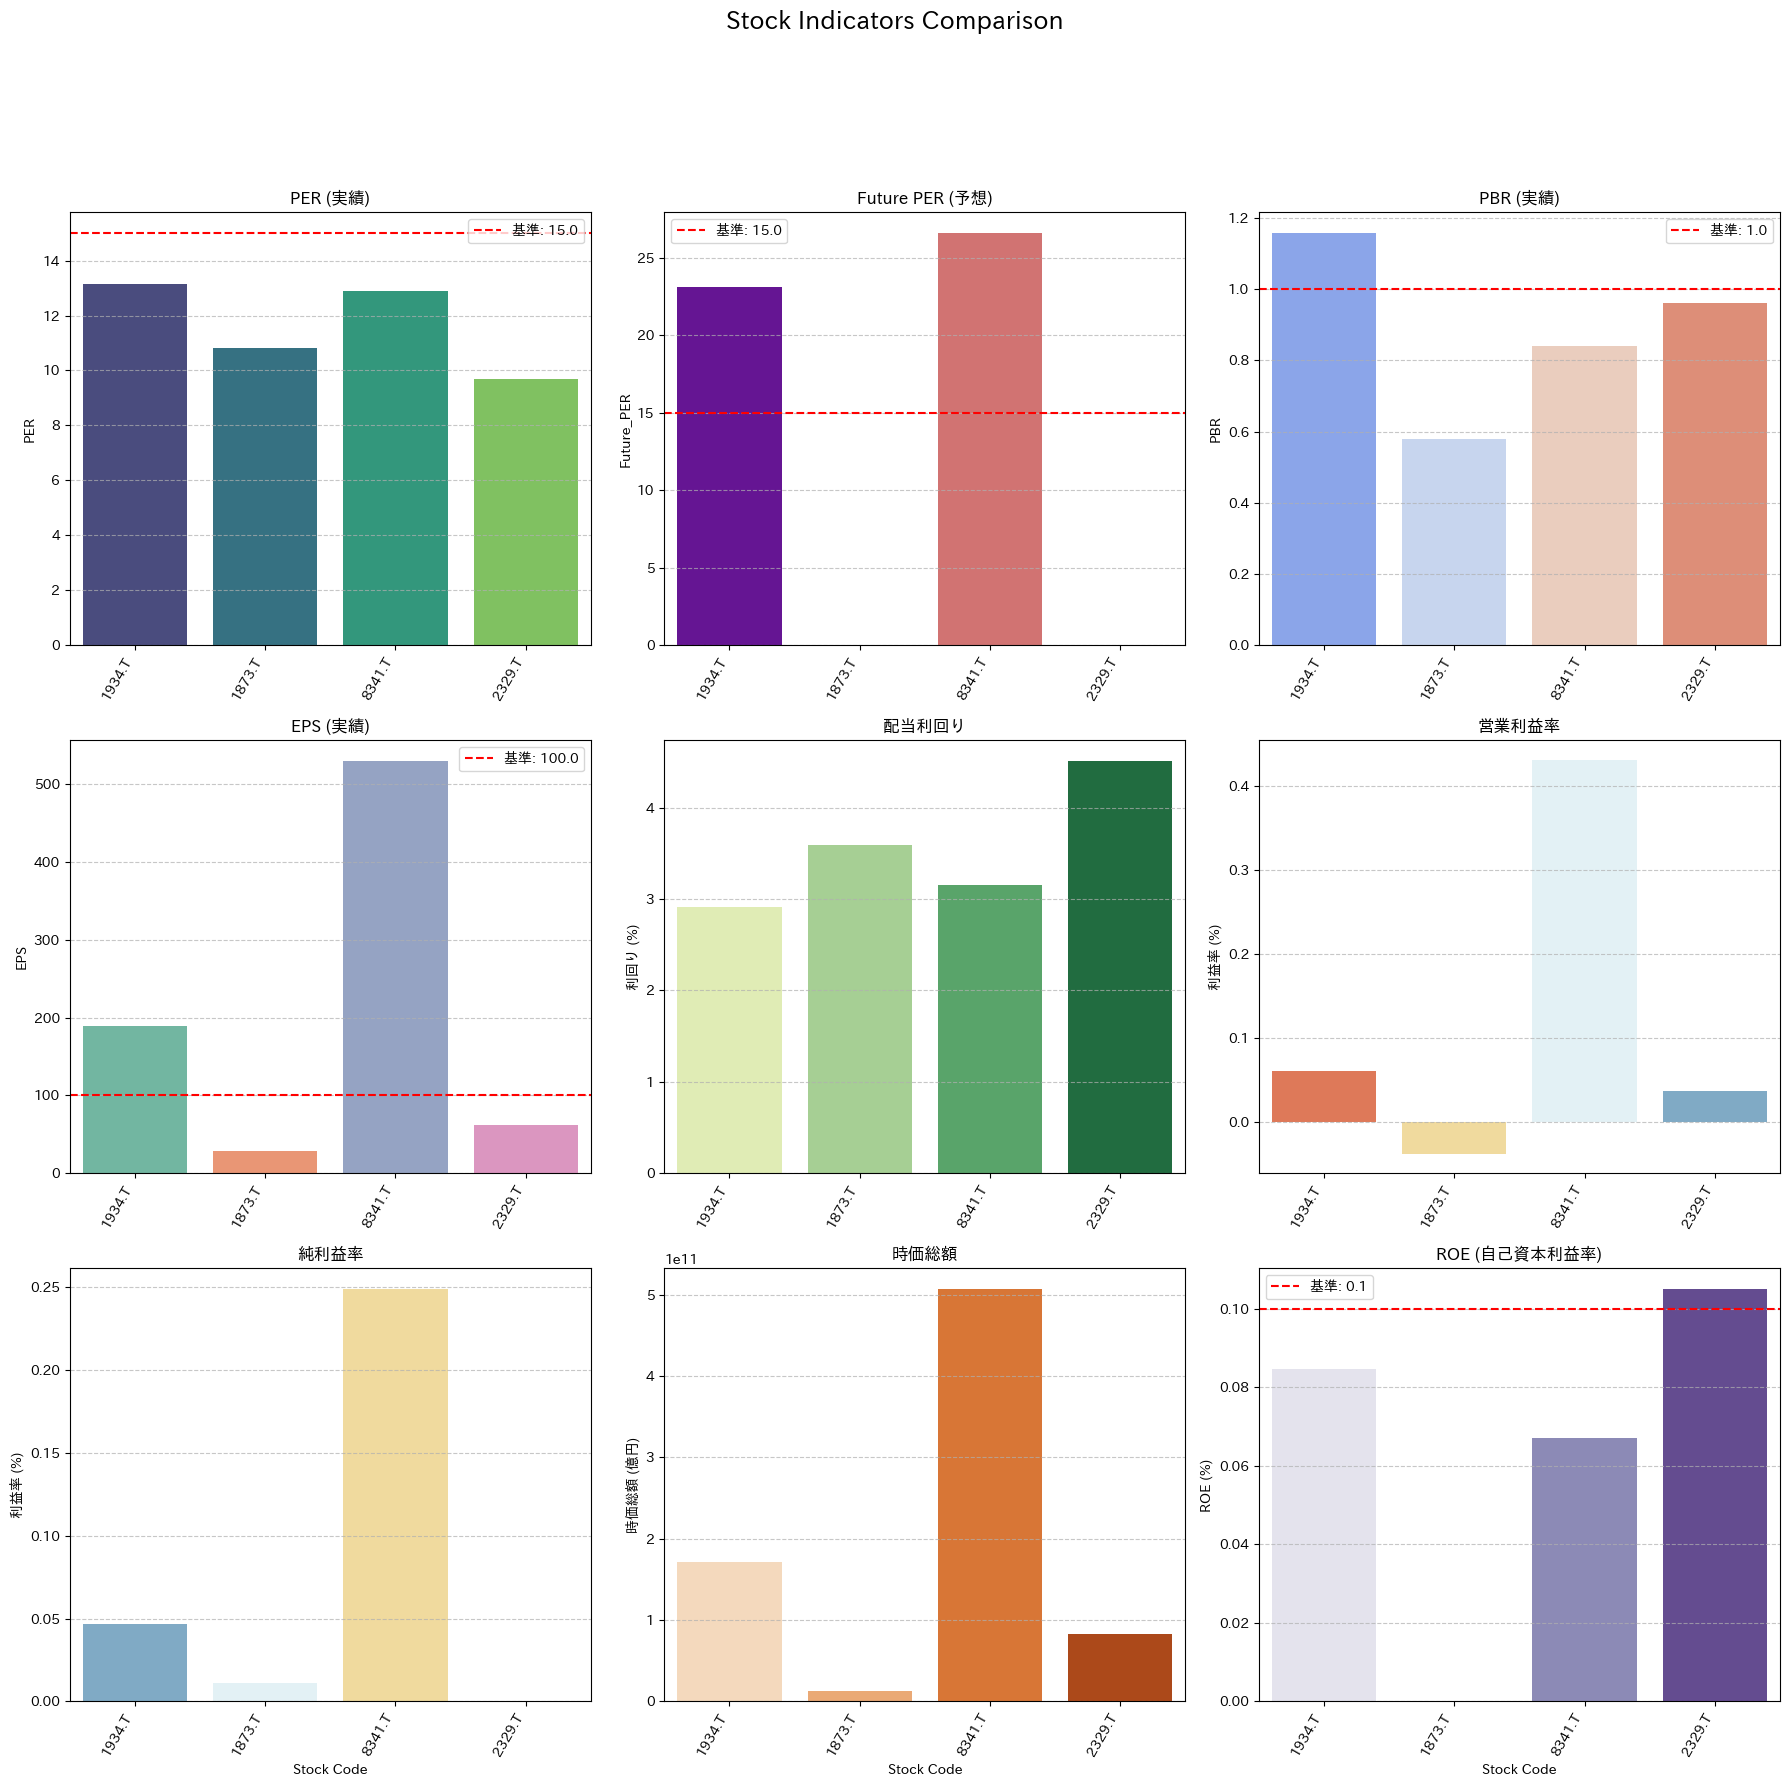

In [222]:

per_ref_line = 15.0      # PERの基準線
future_per_ref_line = 15.0 # Future PERの基準線
pbr_ref_line = 1.0       # PBRの基準線 (例: 1倍)
eps_ref_line = 100.0     # EPSの基準線 (例: 100円)
roe_ref_line = 0.1 # (例: 10%)

#xx=auto

fig, ax = plt.subplots(3, 3, figsize=(18, 18)) # (3x3 に変更)
fig.suptitle('Stock Indicators Comparison', fontsize=18, y=1.02)

# --- 1行目 ---
# PER (0,0)
sns.barplot(x='Code', y='PER', data=xx, ax=ax[0,0], palette='viridis')
ax[0,0].set_title('PER (実績)')
ax[0,0].axhline(y=per_ref_line, color='red', linestyle='--', label=f'基準: {per_ref_line}')
ax[0,0].legend() 

# Future PER (0,1)
sns.barplot(x='Code', y='Future_PER', data=xx, ax=ax[0,1], palette='plasma')
ax[0,1].set_title('Future PER (予想)')
ax[0,1].axhline(y=future_per_ref_line, color='red', linestyle='--', label=f'基準: {future_per_ref_line}')
ax[0,1].legend()

# PBR (0,2)
sns.barplot(x='Code', y='PBR', data=xx, ax=ax[0,2], palette='coolwarm')
ax[0,2].set_title('PBR (実績)')
ax[0,2].axhline(y=pbr_ref_line, color='red', linestyle='--', label=f'基準: {pbr_ref_line}')
ax[0,2].legend()

# --- 2行目 ---
# EPS (1,0)
sns.barplot(x='Code', y='EPS', data=xx, ax=ax[1,0], palette='Set2')
ax[1,0].set_title('EPS (実績)')
ax[1,0].axhline(y=eps_ref_line, color='red', linestyle='--', label=f'基準: {eps_ref_line}')
ax[1,0].legend()

# 配当利回り (1,1)
sns.barplot(x='Code', y='Dividend_Yield', data=xx, ax=ax[1,1], palette='YlGn')
ax[1,1].set_title('配当利回り')
ax[1,1].set_ylabel('利回り (%)')

# 営業利益率 (1,2)
sns.barplot(x='Code', y='Operating_Margin', data=xx, ax=ax[1,2], palette='RdYlBu')
ax[1,2].set_title('営業利益率')
ax[1,2].set_ylabel('利益率 (%)')

# --- 3行目 ---
# 純利益率 (2,0)
sns.barplot(x='Code', y='Profit_Margin', data=xx, ax=ax[2,0], palette='RdYlBu_r')
ax[2,0].set_title('純利益率')
ax[2,0].set_ylabel('利益率 (%)')

# 時価総額 (2,1)
sns.barplot(x='Code', y='Market_cap', data=xx, ax=ax[2,1], palette='Oranges')
ax[2,1].set_title('時価総額')
ax[2,1].set_ylabel('時価総額 (億円)')

# ▼ (修正) ROE を (2,2) に追加
sns.barplot(x='Code', y='ROE', data=xx, ax=ax[2,2], palette='Purples')
ax[2,2].set_title('ROE (自己資本利益率)')
ax[2,2].set_ylabel('ROE (%)')
ax[2,2].axhline(y=roe_ref_line, color='red', linestyle='--', label=f'基準: {roe_ref_line}')
ax[2,2].legend()


# --- 5. レイアウトの調整 ---
for subplot in ax.flat:
    subplot.grid(axis='y', linestyle='--', alpha=0.7)
    subplot.set_xticklabels(subplot.get_xticklabels(), rotation=60, ha='right')
    subplot.set_xlabel('') 

# ▼ (修正) 一番下のプロット (3行目) にだけX軸ラベルを表示
ax[2,0].set_xlabel('Stock Code')
ax[2,1].set_xlabel('Stock Code')
ax[2,2].set_xlabel('Stock Code')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 機関投資家と信用残高の表示：



In [2]:
import yfinance as yf

# 例: トヨタ (7203.T)
ticker = yf.Ticker("7203.T")

# 機関投資家の保有状況を取得
holders = ticker.institutional_holders

print("--- 機関投資家の保有状況 (上位) ---")
print(holders.head()) # .head() で上位5件を表示

#　信用残高に関しては情報なし＿別途取得する必要があるみたい

--- 機関投資家の保有状況 (上位) ---
  Date Reported                                  Holder  pctHeld  Shares  \
0    2025-06-30  Williams Jones Wealth Management, LLC.      0.0   15000   
1    2025-09-30                    Pacer Advisors, Inc.      0.0  126502   

       Value  pctChange  
0   47205000     0.0000  
1  398101794    -0.0121  
